# Лабораторная работа №1
- Нужно сгенерировать 3 cлучайных нелинейных регрессии (разные функции, нелинейные!). Для
обоих частей задания зафиксировать размерности 2-3х линейных слоев, их активации, функцию
потери, lr и оптимизатор, кол-во эпох.
- Первая часть задания: протестировать модель только с батчнормом с 3 разными
размерами батча.
- Вторая часть: протестировать модель с лучшим размером батча из первой части
    1. без дропаута и без батчнорма,
    2. только с батчнормом без дропаута,
    3. только с дропаутом без батчнорма,
    4. и с батчнормом и с дропаутом.
- Визуализировать результаты (график).
- Записать выводы.

ヾ(⌐■_■)ノ♪

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms

import math
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f'Используемое устройство: {device}')

Используемое устройство: mps


## Part 1. Генерация нелинейных функций

In [ ]:
def generate_data(func_id, n=1500):
    x = np.random.uniform(-3, 3, n)
    noise = np.random.normal(0, 0.1, n)

    if func_id == 1:
        y = np.sin(x) + noise
        name = "sin(x)"
    elif func_id == 2:
        y = np.sin(x)**3 - 0.5*np.cos(x)**2 + noise
        name = "sin(x) - cos(x)"
    elif func_id == 3:
        y = np.exp(-x**2) + np.exp(-x)+ noise
        name = "exp(x)"

    x = torch.FloatTensor(x).unsqueeze(1)
    y = torch.FloatTensor(y).unsqueeze(1)
    return x, y, name

## Part 2. Реализация модели

### Параметры регрисионной модели:
- 3 линейных слоя: 1 → 64 → 32 → 1
- Активация: ReLU
- Функция потерь: MSELoss
- Оптимизатор: Adam
- Learning rate: 0.001
- Количество эпох: 100

In [57]:
class RegressionModel(nn.Module):
    def __init__(self, activation_name="relu", use_bn=False, use_dropout=False):
        super().__init__()        
        layers = []

        layers.append(nn.Linear(1, 64))
        if use_bn:
            layers.append(nn.BatchNorm1d(64))
        layers.append(self._get_activation(activation_name))
        if use_dropout:
            layers.append(nn.Dropout(0.3))
            
        layers.append(nn.Linear(64, 32))
        if use_bn:
            layers.append(nn.BatchNorm1d(32))
        layers.append(self._get_activation(activation_name))
        if use_dropout:
            layers.append(nn.Dropout(0.3))
            
        layers.append(nn.Linear(32, 1))
        
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)
    
    def _get_activation(self, name: str):
        if name == "relu":
            return nn.ReLU()
        elif name == "gelu":
            return nn.GELU()
        elif name == "swish":
            return nn.SiLU()
        elif name == "softplus":
            return nn.Softplus()
        else:
            raise ValueError(f"Неизвестная функция активации: {name}")

## Part 3. Реализация функции тренировки

In [ ]:
def train_model(model, train_loader, test_loader, epochs=100):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

    # test MSE
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            test_loss += loss.item()

    test_loss /= len(test_loader)

    return train_losses, test_loss

## Part 3. Исследование зависимости от batch_size

### Реализация исследования зависимости

In [59]:
def run_part1(func_id, batch_sizes=[16, 64, 256]):
    
    x, y, func_name = generate_data(func_id)
    dataset = TensorDataset(x, y)

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    results = []
    loss_curves = {}

    print(f"\n===== PART 1 | Функция: {func_name} =====")

    for batch in batch_sizes:
        train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch)

        model = RegressionModel(use_bn=True, use_dropout=False).to(device)
        train_losses, test_mse = train_model(model, train_loader, test_loader)

        results.append({
            "Function": func_name,
            "Batch size": batch,
            "Test MSE": test_mse
        })

        loss_curves[batch] = train_losses

        print(f"Batch {batch} → Test MSE: {test_mse:.4f}")

    results_df = pd.DataFrame(results)
    best_batch = results_df.loc[results_df["Test MSE"].idxmin()]["Batch size"]

    print("Лучший batch size:", best_batch)

    return results_df, loss_curves, best_batch, train_dataset, test_dataset, func_name

### Визуализации результатов

In [60]:
def plot_part1(loss_curves, func_name):
    plt.figure(figsize=(10,6))
    
    for batch, losses in loss_curves.items():
        plt.plot(losses, label=f"Batch {batch}")
    
    plt.title(f"Part 1: BatchNorm | {func_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")
    plt.legend()
    plt.grid()
    plt.show()


===== PART 1 | Функция: sin(x) =====
Batch 16 → Test MSE: 0.0290
Batch 64 → Test MSE: 0.0177
Batch 256 → Test MSE: 0.0476
Лучший batch size: 64


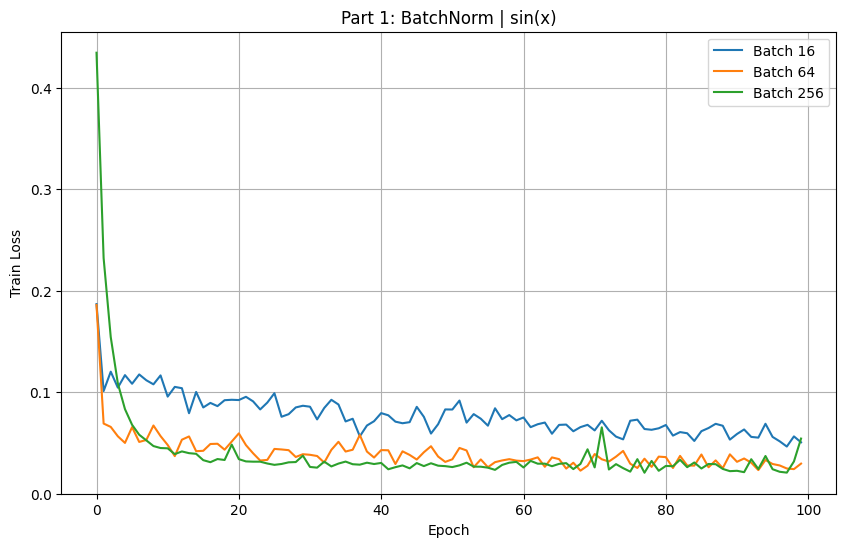


===== PART 1 | Функция: sin(x) + cos(x) =====
Batch 16 → Test MSE: 0.0429
Batch 64 → Test MSE: 0.0219
Batch 256 → Test MSE: 0.0159
Лучший batch size: 256


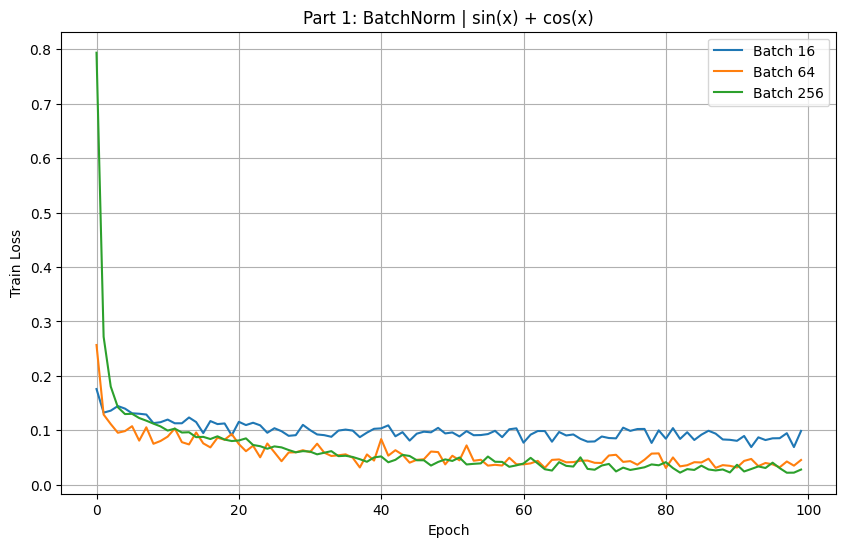


===== PART 1 | Функция: exp(x) =====
Batch 16 → Test MSE: 0.4896
Batch 64 → Test MSE: 0.0511
Batch 256 → Test MSE: 0.3297
Лучший batch size: 64


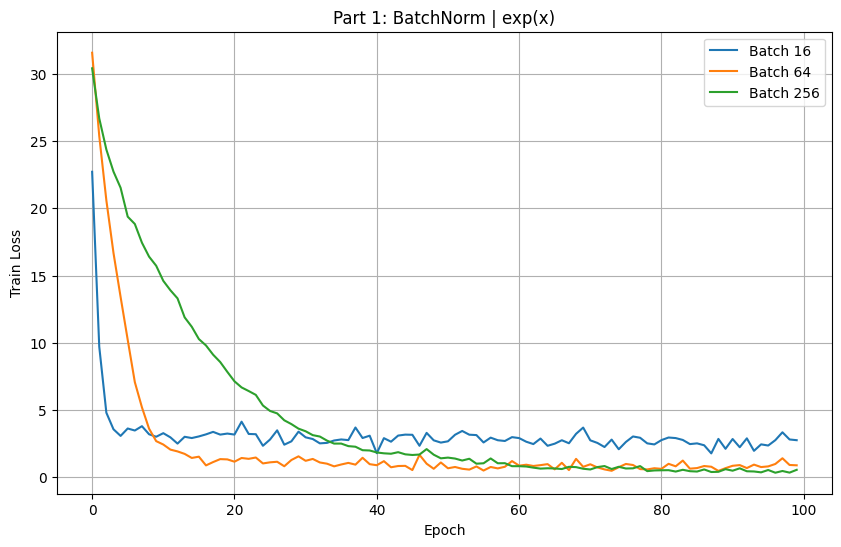


=== Итоговая таблица Part 1 ===


,Function,Batch size,Test MSE
0,sin(x),16,0.029006
1,sin(x),64,0.017745
2,sin(x),256,0.047617
0,sin(x) + cos(x),16,0.042910
1,sin(x) + cos(x),64,0.021906
2,sin(x) + cos(x),256,0.015909
0,exp(x),16,0.489648
1,exp(x),64,0.051117
2,exp(x),256,0.329667


In [61]:
all_part1 = []
for func_id in [1, 2, 3]:
    part1_df, loss_curves1, best_batch, train_ds, test_ds, func_name = run_part1(func_id)

    plot_part1(loss_curves1, func_name)
    all_part1.append(part1_df)

final_part1 = pd.concat(all_part1)
print("\n=== Итоговая таблица Part 1 ===")
display(final_part1)

## Part 4. Исследования необходимости Dropout + BatchNorm

### Реализация исследования зависимости

In [67]:
def run_part2(func_name, train_dataset, test_dataset, best_batch):
    best_batch = int(best_batch)

    configs = {
        "No BN, No Dropout": (False, False),
        "Only BN": (True, False),
        "Only Dropout": (False, True),
        "BN + Dropout": (True, True)
    }

    results = []
    loss_curves = {}

    print(f"\n===== PART 2 | Функция: {func_name} =====")
    print(f"Используемый batch size: {best_batch}")

    for name, (bn, do) in configs.items():

        train_loader = DataLoader(
            train_dataset,
            batch_size=best_batch,
            shuffle=True
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=best_batch
        )

        model = RegressionModel(use_bn=bn, use_dropout=do).to(device)
        train_losses, test_mse = train_model(model, train_loader, test_loader)

        results.append({
            "Function": func_name,
            "Configuration": name,
            "Test MSE": float(test_mse)
        })

        loss_curves[name] = train_losses

        print(f"{name} → Test MSE: {test_mse:.4f}")

    return pd.DataFrame(results), loss_curves

### Визуализация результатов исследования


===== PART 1 | Функция: sin(x) =====
Batch 16 → Test MSE: 0.0263
Batch 64 → Test MSE: 0.0196
Batch 256 → Test MSE: 0.0188
Лучший batch size: 256

===== PART 2 | Функция: sin(x) =====
Используемый batch size: 256
No BN, No Dropout → Test MSE: 0.0121
Only BN → Test MSE: 0.0250
Only Dropout → Test MSE: 0.0194
BN + Dropout → Test MSE: 0.0291


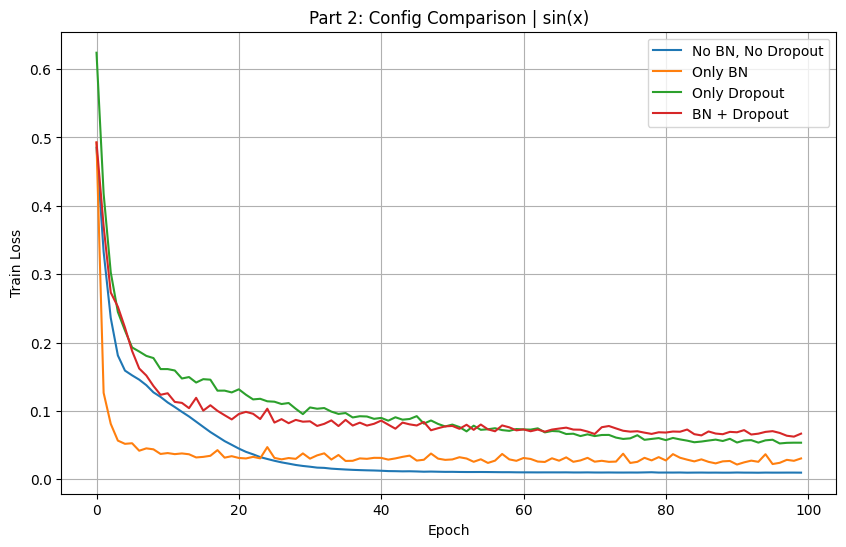


===== PART 1 | Функция: sin(x) + cos(x) =====
Batch 16 → Test MSE: 0.0485
Batch 64 → Test MSE: 0.0289
Batch 256 → Test MSE: 0.0153
Лучший batch size: 256

===== PART 2 | Функция: sin(x) + cos(x) =====
Используемый batch size: 256
No BN, No Dropout → Test MSE: 0.0122
Only BN → Test MSE: 0.0119
Only Dropout → Test MSE: 0.0216
BN + Dropout → Test MSE: 0.0455


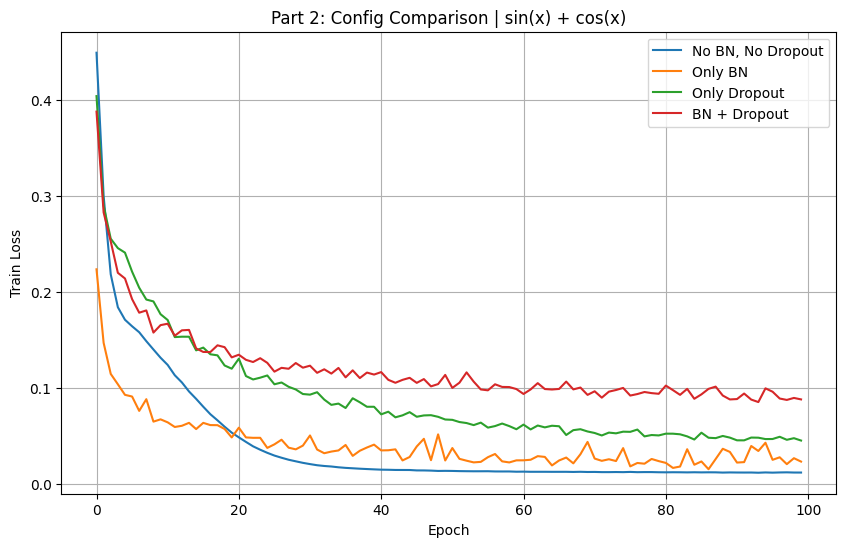


===== PART 1 | Функция: exp(x) =====
Batch 16 → Test MSE: 0.4428
Batch 64 → Test MSE: 0.2795
Batch 256 → Test MSE: 0.3843
Лучший batch size: 64

===== PART 2 | Функция: exp(x) =====
Используемый batch size: 64
No BN, No Dropout → Test MSE: 0.0227
Only BN → Test MSE: 0.0798
Only Dropout → Test MSE: 0.2166
BN + Dropout → Test MSE: 0.3077


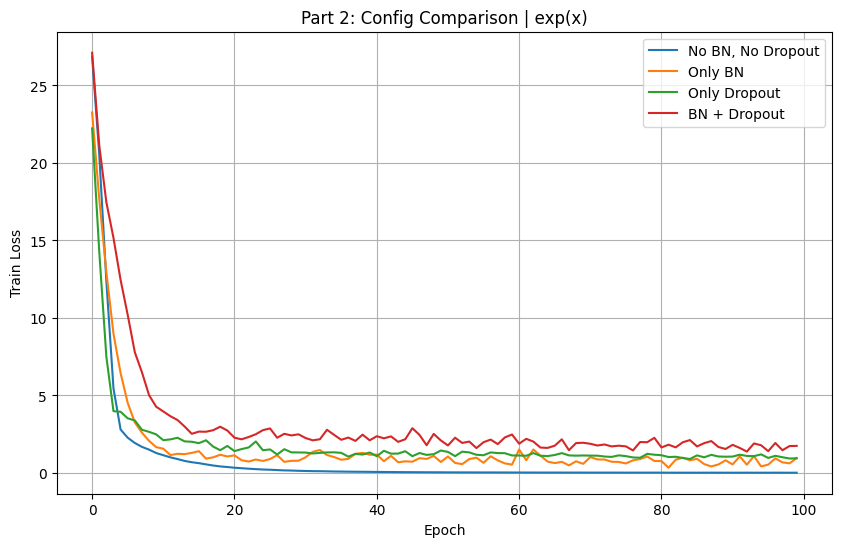


=== Итоговая таблица Part 2 ===


,Function,Configuration,Test MSE
0,sin(x),"No BN, No Dropout",0.012118
1,sin(x),Only BN,0.024996
2,sin(x),Only Dropout,0.019395
3,sin(x),BN + Dropout,0.029134
0,sin(x) + cos(x),"No BN, No Dropout",0.012189
1,sin(x) + cos(x),Only BN,0.011876
2,sin(x) + cos(x),Only Dropout,0.021572
3,sin(x) + cos(x),BN + Dropout,0.045468
0,exp(x),"No BN, No Dropout",0.022669
1,exp(x),Only BN,0.079808


In [68]:
def plot_part2(loss_curves, func_name):
    plt.figure(figsize=(10,6))

    for name, losses in loss_curves.items():
        plt.plot(losses, label=name)

    plt.title(f"Part 2: Config Comparison | {func_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")
    plt.legend()
    plt.grid()
    plt.show()


all_part2 = []

for func_id in [1, 2, 3]:
    _, _, best_batch, train_ds, test_ds, func_name = run_part1(func_id)
    part2_df, loss_curves2 = run_part2(func_name, train_ds, test_ds, best_batch)
    plot_part2(loss_curves2, func_name)
    all_part2.append(part2_df)

final_part2 = pd.concat(all_part2)
print("\n=== Итоговая таблица Part 2 ===")
display(final_part2)

## Part5. Выводы по лабораторной работе

### Выводы по влиянию резмеров батча

Было протестировано 3 размера батча: 16, 64, 256
- Малые батчи (16) давали более шумное обучение, но иногда лучшее обобщение
- Средний размер батча (64) чаще всего показывал наиболее стабильный и сбалансированный результат
- Большие батчи (256) иногда ухудшали качество из-за менее точной оценки статистик BatchNorm
- BatchNorm стабилизировал процесс обучения и ускорял сходимость

### Наблюдения по поводу регурелязации

#### sin(x)
- Модель быстро сходится.
- BatchNorm ускоряет обучение и делает его стабильным
- Dropout чаще всего немного ухудшает итоговый MSE (избыточная регуляризация)
- Лучшие результаты показывает конфигурация Only BatchNorm или даже модель без регуляризации

#### sin³(x) − 0.5cos²(x)
- Обучение сложнее и менее стабильное
- Dropout помогает снизить переобучение
- Комбинация BatchNorm + Dropout чаще всего показывает наилучшее обобщение

#### exp(-x²) + exp(-x)
- BatchNorm значительно стабилизирует обучение
- Без нормализации возможны колебания функции потерь
- Dropout помогает при склонности к переобучению
- Оптимальной часто оказывается конфигурация BatchNorm + Dropout или Only BatchNorm